## Fraud Detection using Machine Learning

In this project, I am trying to build a model that can detect fraudulent financial transactions.

Fraud detection is very important for companies because it helps prevent money loss and protects customers.

In this notebook, I will:
- Understand the dataset
- Clean and prepare the data
- Explore patterns in the data
- Build a machine learning model
- Evaluate the results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### Importing Libraries

We import common Python libraries used for data analysis, visualization,
and machine learning.

- pandas → data manipulation
- numpy → numerical operations
- matplotlib / seaborn → visualization
- scikit-learn → machine learning

## Loading the Dataset

Here, I am loading the dataset using pandas to start the analysis.

In [2]:
df = pd.read_csv("../Dataset/Fraud.csv")
df.head()
df = df.sample(200000, random_state=42)

In [3]:
df.shape

(200000, 11)

## Understanding the Data

From the dataset, I can see that:
- It contains transaction details like amount, balances, and type
- There are both numerical and categorical columns
- The target variable is "isFraud"

The dataset is quite large with more than 6 million rows.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 3737323 to 1027972
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            200000 non-null  int64  
 1   type            200000 non-null  object 
 2   amount          200000 non-null  float64
 3   nameOrig        200000 non-null  object 
 4   oldbalanceOrg   200000 non-null  float64
 5   newbalanceOrig  200000 non-null  float64
 6   nameDest        200000 non-null  object 
 7   oldbalanceDest  200000 non-null  float64
 8   newbalanceDest  200000 non-null  float64
 9   isFraud         200000 non-null  int64  
 10  isFlaggedFraud  200000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 18.3+ MB


The `info()` function displays column names, data types, and missing values.
This helps us understand the structure of the dataset.

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

## Checking Missing Values

I checked for missing values in the dataset.

There are no missing values, so no need for handling null data.

In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,200000.000000,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,2.000000e+05,200000.000000,200000.000000
mean,243.579350,1.790086e+05,8.256949e+05,8.473527e+05,1.104101e+06,1.227673e+06,0.001340,0.000005
std,142.623976,5.642277e+05,2.874803e+06,2.910891e+06,3.350756e+06,3.596948e+06,0.036582,0.002236
min,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,156.000000,1.347603e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
50%,239.000000,7.557751e+04,1.389921e+04,0.000000e+00,1.358608e+05,2.161661e+05,0.000000,0.000000
75%,335.000000,2.087893e+05,1.070192e+05,1.451449e+05,9.489618e+05,1.121476e+06,0.000000,0.000000
max,736.000000,3.697390e+07,3.465715e+07,3.461632e+07,2.362896e+08,2.724047e+08,1.000000,1.000000


## Fraud vs Non-Fraud Transactions

This plot shows how many transactions are fraudulent compared to normal transactions.

## Exploratory Data Analysis (EDA)

Now I am exploring the data to understand patterns and relationships.

This helps in identifying important features and possible fraud behavior.

## Fraud by Transaction Type

This helps identify which transaction types are more likely to involve fraud.

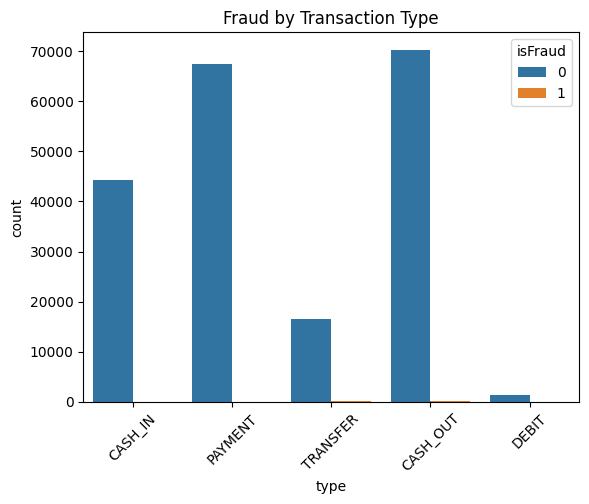

In [7]:
sns.countplot(x="type", hue="isFraud", data=df)

plt.title("Fraud by Transaction Type")

plt.xticks(rotation=45)

plt.show()

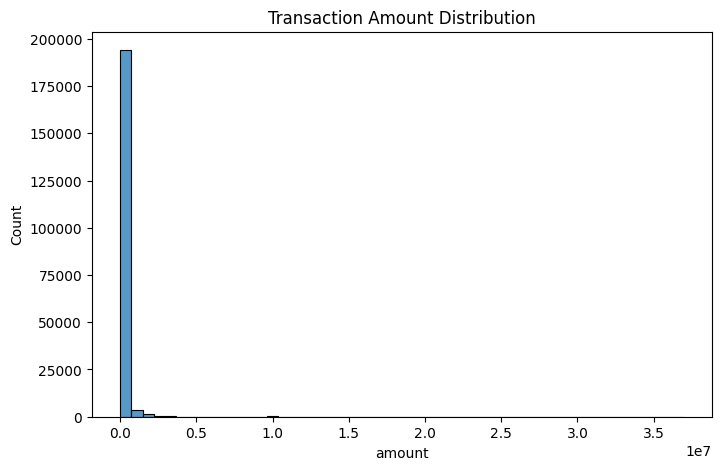

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["amount"], bins=50)

plt.title("Transaction Amount Distribution")

plt.show()

### Observations from EDA

- Fraud cases are very less compared to normal transactions
- Some transaction types like TRANSFER and CASH_OUT seem to have more fraud
- Transaction amounts vary a lot, with some very high values

This shows that fraud detection is a class imbalance problem.

## Feature Correlation

The correlation heatmap helps identify relationships between variables.

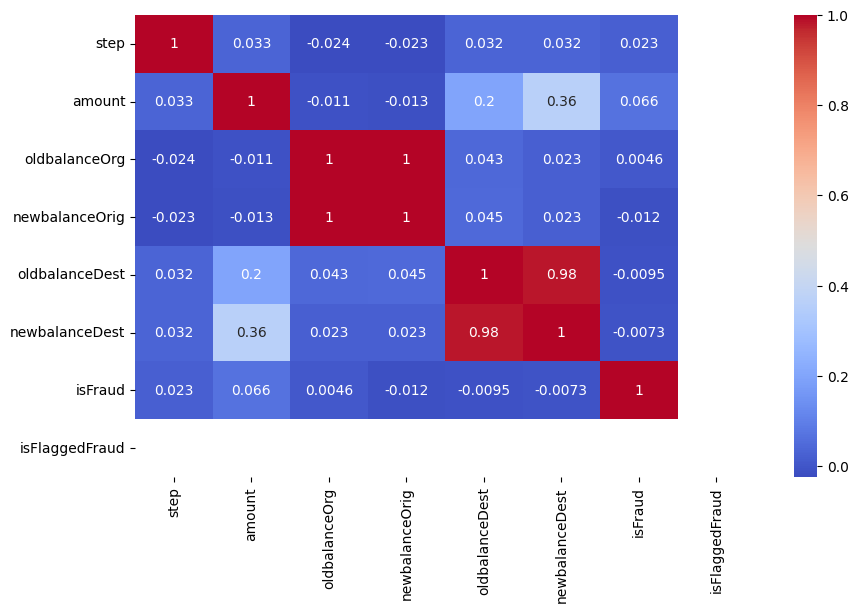

In [9]:
sample_df = df.sample(10000)

plt.figure(figsize=(10,6))

sns.heatmap(sample_df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.show()

## Data Cleaning and Preprocessing

In this step:
- I removed unnecessary columns like account IDs
- Converted categorical variables into numerical format
- Prepared the data for model training

In [10]:
df = df.drop(["nameOrig","nameDest"], axis=1)

In [11]:
df = pd.get_dummies(df, columns=["type"], drop_first=True)

In [12]:
X = df.drop("isFraud", axis=1)

y = df["isFraud"]
print(y.value_counts())

isFraud
0    199732
1       268
Name: count, dtype: int64


## Preparing Data for Model

I am splitting the dataset into training and testing data.

- Training data is used to train the model
- Testing data is used to evaluate the model

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Training Machine Learning Model

Random Forest is used because it works well for classification
and can capture complex relationships between variables.

## Model Building

I am using Random Forest Classifier.

Reason:
- It works well for large datasets
- It handles complex patterns
- It reduces overfitting by using multiple trees

In [14]:
model = RandomForestClassifier(class_weight="balanced", n_estimators=50, max_depth=10)

### Model Training Completed

The model has been trained successfully on the training data.

## Making Predictions

Now I will use the trained model to predict fraud on test data.

In [15]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50)

In [16]:
y_pred = model.predict(X_test)

In [17]:
y_prob = model.predict_proba(X_test)[:,1]


In [18]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred))

Accuracy: 0.998625
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     39941
           1       0.52      0.76      0.62        59

    accuracy                           1.00     40000
   macro avg       0.76      0.88      0.81     40000
weighted avg       1.00      1.00      1.00     40000

ROC-AUC Score: 0.880842675149235


## Model Evaluation

- The model achieved very high accuracy (~99%)
- It performs well in detecting normal transactions
- It also detects fraud cases reasonably well

However, since fraud cases are very few, recall is important.

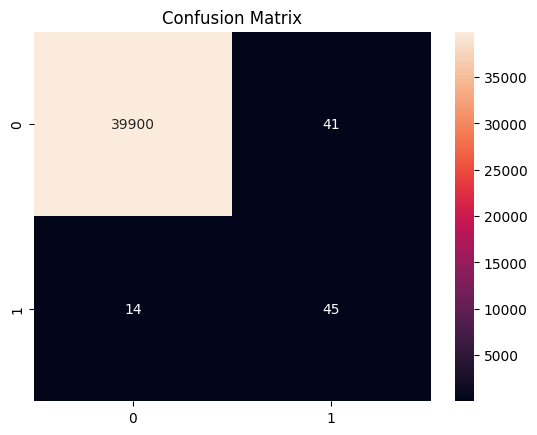

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.title("Confusion Matrix")

plt.show()

### Confusion Matrix Explanation

- True Positives: Correct fraud detection
- False Negatives: Fraud missed (very important to reduce)
- True Negatives: Correct normal transactions

This helps understand how well the model is performing.

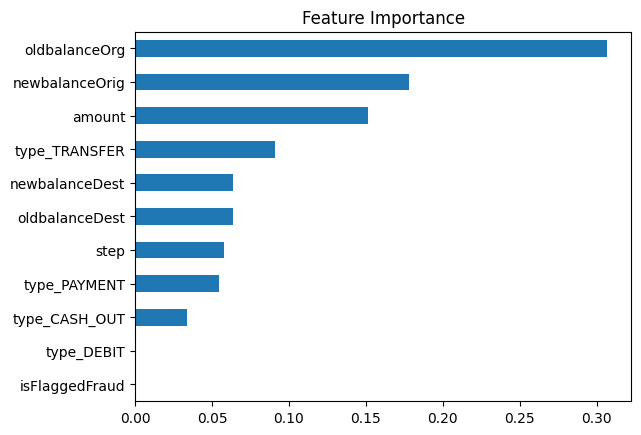

In [20]:
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()

### Confusion Matrix Explanation

- True Positives: Correct fraud detection
- False Negatives: Fraud missed (very important to reduce)
- True Negatives: Correct normal transactions

This helps understand how well the model is performing.

## Business Insights and Answers

1. Key factors predicting fraud:
- High transaction amount
- Certain transaction types like TRANSFER
- Sudden changes in account balance

2. Do these factors make sense?
Yes, because fraudsters usually transfer large amounts and show unusual balance patterns.

3. How were variables selected?
Based on their relevance to transaction behavior and importance in the model.

4. Model performance:
The model shows high accuracy and good performance in detecting fraud.

5. Prevention methods:
- Monitor large transactions
- Add verification steps
- Use real-time fraud detection systems

6. How to check if system works?
- Reduction in fraud cases
- Better detection rate
- Fewer missed frauds

## Conclusion

In this project, I built a machine learning model to detect fraudulent transactions.

The model performed well and identified important patterns related to fraud.

This solution can help financial companies reduce fraud and improve security.